## Imports

In [4]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes
# Fit a Generalized Additive Model (GAM) to the interpolated progeria data
from pygam import LinearGAM, s


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th


Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl


## Param Variation Changes

In [ ]:
dict = utils.load_baseline_human_params_dict()
dict['Xc'] = 0.97*dict['Xc']
dict['epsilon'] = 1.05*dict['epsilon']
dict['eta'] = 0.96*dict['eta']

th.run_parameter_study(study_type = 'variation' , name = 'usa_2019', baseline_dict = dict)

Processing parameter: eta
  Std: 0.00 completed
  Std: 0.01 completed
  Std: 0.02 completed
  Std: 0.03 completed
  Std: 0.04 completed
  Std: 0.05 completed
  Std: 0.06 completed
  Std: 0.07 completed
  Std: 0.08 completed
  Std: 0.09 completed
  Std: 0.10 completed
  Std: 0.11 completed
  Std: 0.12 completed
  Std: 0.13 completed
  Std: 0.14 completed
  Std: 0.15 completed
  Std: 0.16 completed
  Std: 0.17 completed
  Std: 0.18 completed
  Std: 0.19 completed
  Std: 0.20 completed
Processing parameter: beta
  Std: 0.00 completed
  Std: 0.01 completed
  Std: 0.02 completed
  Std: 0.03 completed
  Std: 0.04 completed
  Std: 0.05 completed
  Std: 0.06 completed
  Std: 0.07 completed
  Std: 0.08 completed
  Std: 0.09 completed
  Std: 0.10 completed
  Std: 0.11 completed
  Std: 0.12 completed
  Std: 0.13 completed
  Std: 0.14 completed
  Std: 0.15 completed
  Std: 0.16 completed
  Std: 0.17 completed
  Std: 0.18 completed
  Std: 0.19 completed
  Std: 0.20 completed
Processing parameter: e

{'baseline': {0: {'steepness_iqr_relative': 7.398656417768416,
   'steepness_iqr_absolute': 7.398656417768416,
   'steepness_cv_relative': 9.37512035850516,
   'steepness_cv_absolute': 9.37512035850516,
   't_median_relative': 84.76027696793004,
   't_median_absolute': 84.76027696793004,
   't_max': 107.56250000000001},
  15: {'steepness_iqr_relative': 6.089347264742924,
   'steepness_iqr_absolute': 7.398690708097322,
   'steepness_cv_relative': 7.6976869480612065,
   'steepness_cv_absolute': 9.376087845188357,
   't_median_relative': 69.76031341107871,
   't_median_absolute': 84.76031341107871,
   't_max': 107.56250125000001},
  20: {'steepness_iqr_relative': 5.652899450291457,
   'steepness_iqr_absolute': 7.398690708097322,
   'steepness_cv_relative': 7.138219982352157,
   'steepness_cv_absolute': 9.376087845188357,
   't_median_relative': 64.76031341107871,
   't_median_absolute': 84.76031341107871,
   't_max': 107.56250125000001},
  30: {'steepness_iqr_relative': 4.780190064836212,


Processing parameter: Xc
  Running simulation for Xc factor: 1.00
  Running simulation for Xc factor: 1.05
  Running simulation for Xc factor: 1.10
  Running simulation for Xc factor: 1.15
  Running simulation for Xc factor: 1.20

Processing parameter: epsilon
  Running simulation for epsilon factor: 1.00
  Running simulation for epsilon factor: 0.95
  Running simulation for epsilon factor: 0.90
  Running simulation for epsilon factor: 0.85
  Running simulation for epsilon factor: 0.80

Processing parameter: eta
  Running simulation for eta factor: 1.00
  Running simulation for eta factor: 0.95
  Running simulation for eta factor: 0.90
  Running simulation for eta factor: 0.85
  Running simulation for eta factor: 0.80

Processing parameter: beta
  Running simulation for beta factor: 1.00
  Running simulation for beta factor: 1.05
  Running simulation for beta factor: 1.10
  Running simulation for beta factor: 1.15
  Running simulation for beta factor: 1.20


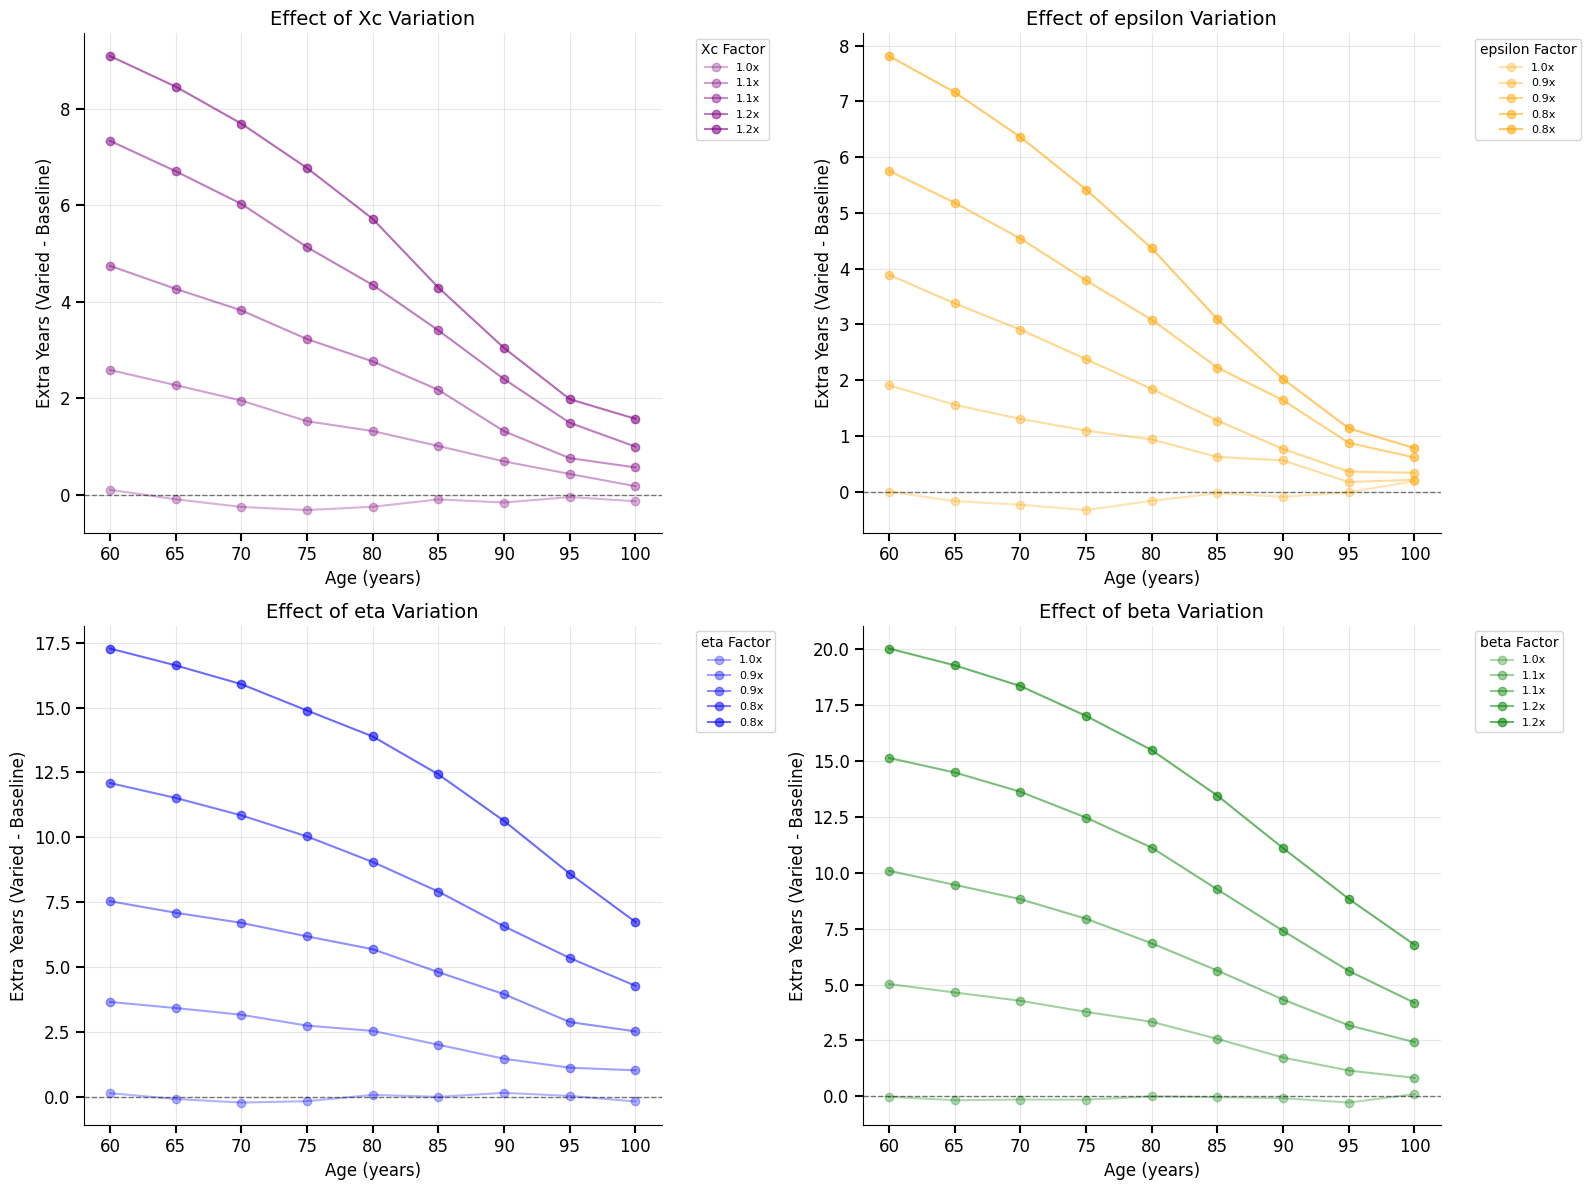

In [17]:
# Define baseline dictionary with specified modifications
baseline_dict = utils.load_baseline_human_params_dict()
baseline_dict['Xc'] = 0.97*baseline_dict['Xc']
baseline_dict['epsilon'] = 1.05*baseline_dict['epsilon']
baseline_dict['eta'] = 0.96*baseline_dict['eta']

# Create baseline simulation
baseline_sim = utils.create_sr_simulation(species='human', n=10000, params_dict=baseline_dict, parallel=False)

# Calculate baseline median lifespans from different ages
ages = np.arange(60, 105, 5)
baseline_medians = {}
for age in ages:
    median_lifespan = baseline_sim.find_time_at_survival(0.5, from_t=age, relative=False)
    if median_lifespan is not None:
        baseline_medians[age] = median_lifespan - age
    else:
        baseline_medians[age] = None

# Define parameters to vary and their factor ranges
params_to_vary = {
    'Xc': np.arange(1.0, 1.21, 0.05),
    'epsilon': np.arange(1.0, 0.79, -0.05),
    'eta': np.arange(1.0, 0.79, -0.05),
    'beta': np.arange(1.0, 1.21, 0.05)
}

# Run simulations for all parameter variations
all_param_results = {}

for param_name, factors in params_to_vary.items():
    print(f"\nProcessing parameter: {param_name}")
    param_results = {}
    
    for factor in factors:
        print(f"  Running simulation for {param_name} factor: {factor:.2f}")
        varied_dict = utils.load_baseline_human_params_dict()
        varied_dict['Xc'] = 0.97*varied_dict['Xc']
        varied_dict['epsilon'] = 1.05*varied_dict['epsilon']
        varied_dict['eta'] = 0.96*varied_dict['eta']
        
        # Apply factor to chosen parameter
        varied_dict[param_name] = factor * varied_dict[param_name]
        
        sim = utils.create_sr_simulation(species='human', n=10000, params_dict=varied_dict, parallel=False)
        
        # Calculate median lifespans from different ages
        factor_medians = {}
        for age in ages:
            median_lifespan = sim.find_time_at_survival(0.5, from_t=age, relative=False)
            if median_lifespan is not None:
                factor_medians[age] = median_lifespan - age
            else:
                factor_medians[age] = None
        
        param_results[factor] = factor_medians
    
    all_param_results[param_name] = param_results

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (param_name, param_results) in enumerate(all_param_results.items()):
    ax = axes[idx]
    factors = params_to_vary[param_name]
    
    for factor in factors:
        extra_years = []
        valid_ages = []
        for age in ages:
            if param_results[factor][age] is not None and baseline_medians[age] is not None:
                extra = param_results[factor][age] - baseline_medians[age]
                extra_years.append(extra)
                valid_ages.append(age)
        
        if len(extra_years) > 0:
            # Calculate alpha based on factor range
            if param_name in ['Xc', 'beta']:
                # For Xc and beta: 1.0 to 1.5
                alpha_value = max(0.0, min(1.0, 0.3 + 0.7*(factor-1.0)/(1.5-1.0)))
            else:
                # For epsilon and eta: 1.0 to 0.5
                alpha_value = max(0.0, min(1.0, 0.3 + 0.7*(1.0-factor)/(1.0-0.5)))
            
            ax.plot(valid_ages, extra_years, marker='o', label=f'{factor:.1f}x', 
                   color=utils.param_colors.get(param_name, 'blue'), alpha=alpha_value)
    
    ax.axhline(y=0.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Age (years)', fontsize=12)
    ax.set_ylabel('Extra Years (Varied - Baseline)', fontsize=12)
    ax.set_title(f'Effect of {param_name} Variation', fontsize=14)
    ax.legend(title=f'{param_name} Factor', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Error: Results file not found at /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/param_variation_results_sweden.pkl


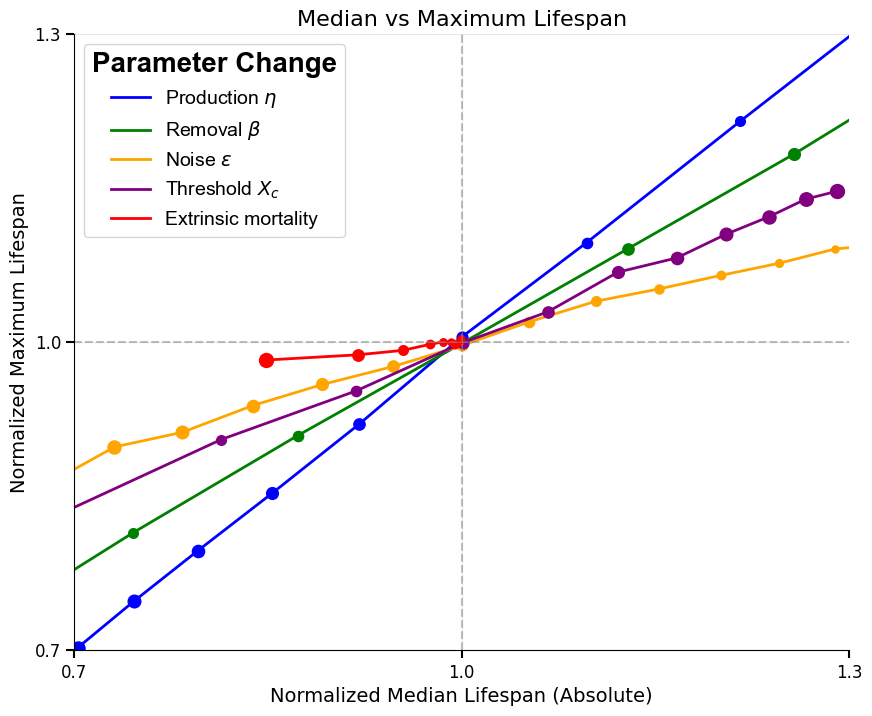

In [8]:
import thresholds_functions as th

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Basic plot (normalized by default)
th.plot_median_max_plane(pkl_file='param_variation_results_sweden.pkl', from_t=20)

# With custom options
th.plot_median_max_plane(
    pkl_file='param_variation_results_usa_2019.pkl',
    param_type='variation',
    from_t=20,
    value_type='normalized',
    h_ext=True,
    ax=ax,
    title='Median vs Maximum Lifespan',
    legend_fontsize = 14
)

xmin = 0.7
xmax = 1.3
ymin = 0.7
ymax = 1.3

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_xticks([xmin, 1.0, xmax])
ax.set_yticks([ymin, 1.0, ymax])

